# 02 — Exploratory Data Analysis (EDA)

**Goal:** Uncover the hidden patterns in household power consumption. We need to understand the relationships between features (correlation), the temporal rhythms (seasonality, intraday cycles), and how historical values influence future values (autocorrelation).

**Prerequisites:** We know from `01` that the data has block-level missing values, is right-skewed, and shows clear daily/yearly cycles. Now we quantify those observations.

---

## 1. Environment Setup & Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import seaborn              as sns
from pandas.plotting import autocorrelation_plot
import statsmodels.api as sm

pd.set_option('display.max_columns',   20)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})
sns.set_palette('husl')
print('Setup complete. Ready for EDA.')

Setup complete. Ready for EDA.


## 2. Load and Prepare Data

We will load the raw data, but this time we'll immediately parse the `Date` and `Time` columns into a single `datetime` index. We will also perform a basic forward-fill for missing values (as decided in notebook 01) to allow for contiguous time-series plotting and autocorrelation calculations.


In [3]:
RAW_PATH = '../data/raw/household_power_consumption.txt'

# Load data
df = pd.read_csv(RAW_PATH, sep=';', na_values='?', low_memory=False)

# Create Datetime Index
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.set_index('datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)

# Forward fill missing values for EDA purposes
# (In actual preprocessing, we might use more sophisticated methods, but ffill is robust for block gaps)
df.ffill(inplace=True)

# Calculate unmetered energy (as discovered in 01)
df['unmetered_energy'] = (df['Global_active_power'] * 1000 / 60) - (df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3'])
# Ensure no negative unmetered energy due to slight measurement errors
df['unmetered_energy'] = df['unmetered_energy'].clip(lower=0)

print(f'Data loaded and prepared. Shape: {df.shape}')
df.head(3)

Data loaded and prepared. Shape: (2075259, 8)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,unmetered_energy
datetime,,,,,,,,
2006-12-16 17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000,52.2667
2006-12-16 17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000,72.3333
2006-12-16 17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000,70.5667


## 3. Resampling for Trend Analysis

Analyzing 2 million rows of minute-by-minute data is noisy. We resample the data into Hourly, Daily, and Monthly aggregates to see macro-level trends.

In [4]:
# Resample
hourly_df = df.resample('H').mean()
daily_df = df.resample('D').sum() # Sum makes sense for daily total consumption
monthly_df = df.resample('M').sum()

print(f'Hourly rows: {hourly_df.shape[0]}')
print(f'Daily rows: {daily_df.shape[0]}')
print(f'Monthly rows: {monthly_df.shape[0]}')

Hourly rows: 34589
Daily rows: 1442
Monthly rows: 48


## 4. Feature Correlation (Pearson)

How do the variables relate to each other linearly? This helps us identify redundant features (multicollinearity) and strong predictors for our target (`Global_active_power`).

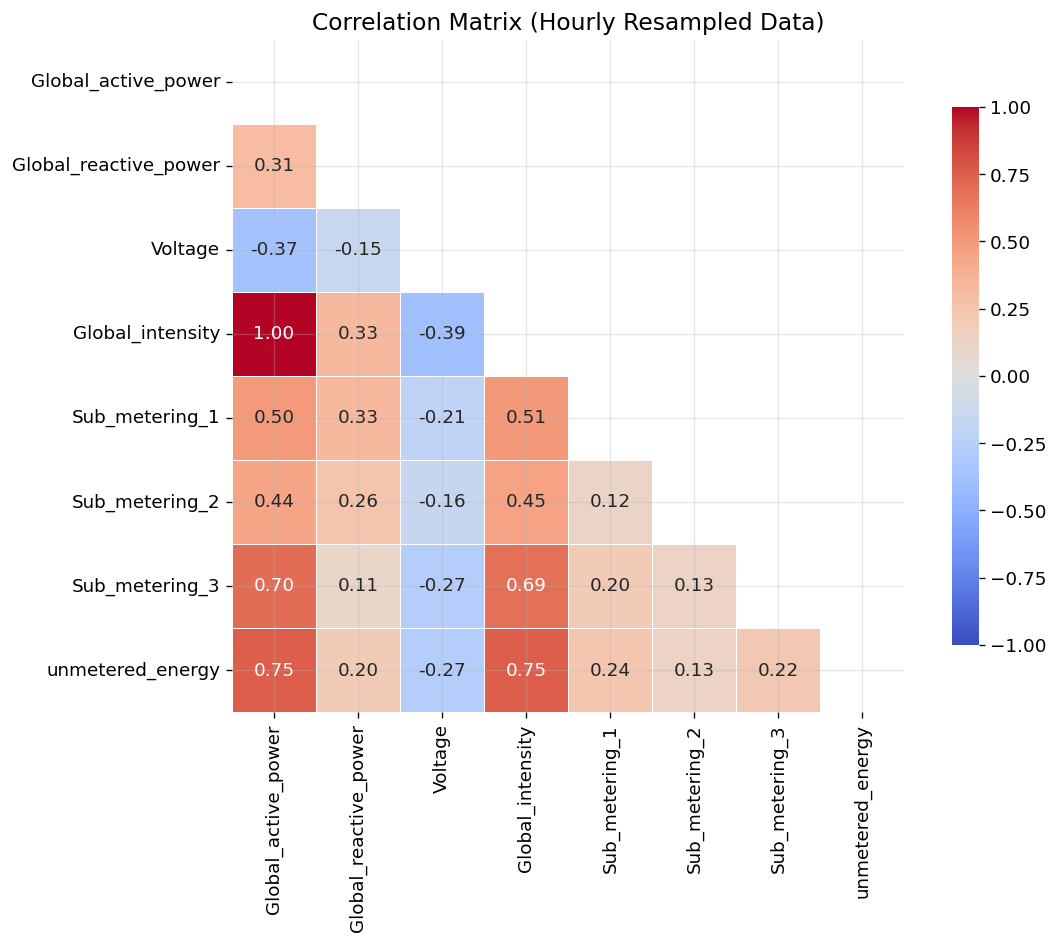

In [5]:
corr = hourly_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={'shrink': .8})
ax.set_title('Correlation Matrix (Hourly Resampled Data)', fontsize=14)
plt.tight_layout(); plt.show()

## 5. Seasonality: Monthly Profiles

Does consumption vary by month? We expect higher usage in winter (heating) and summer (AC, depending on the region). Boxplots show us both the median trend and the variance (how spiky usage is) per month.

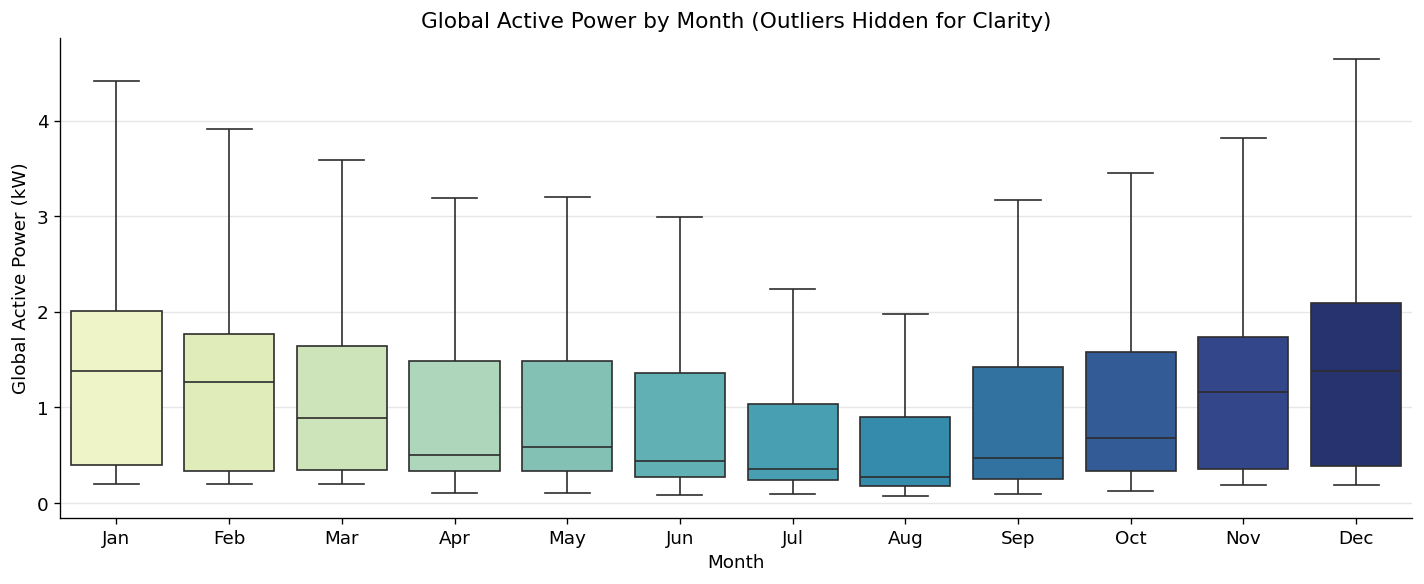

In [6]:
df['Month'] = df.index.month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='Month', y='Global_active_power', 
            palette='YlGnBu', showfliers=False, ax=ax)
ax.set_xticklabels(month_names)
ax.set_title('Global Active Power by Month (Outliers Hidden for Clarity)', fontsize=13)
ax.set_ylabel('Global Active Power (kW)')
plt.tight_layout(); plt.show()

## 6. Intraday Cycles: Hourly Profiles

How does usage change throughout the day? The 'duck curve' is a common pattern in energy consumption.

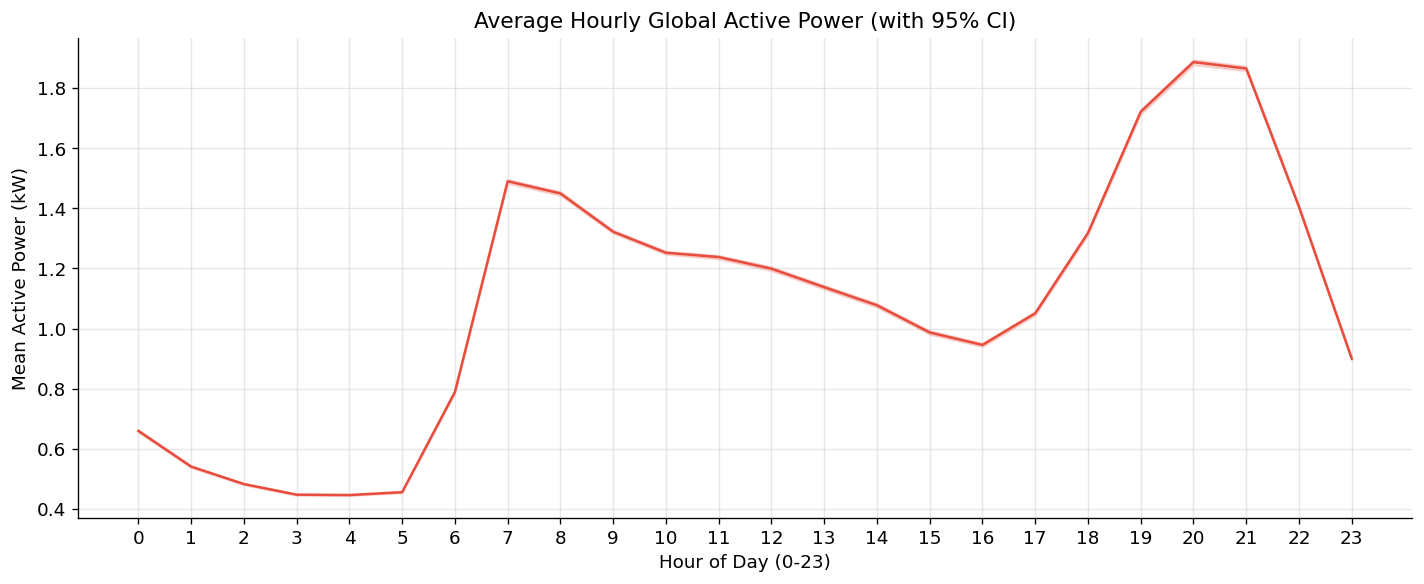

In [7]:
df['Hour'] = df.index.hour

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df, x='Hour', y='Global_active_power', 
             estimator=np.mean, errorbar=('ci', 95), color='#e74c3c', ax=ax)
ax.set_xticks(range(0, 24))
ax.set_title('Average Hourly Global Active Power (with 95% CI)', fontsize=13)
ax.set_xlabel('Hour of Day (0-23)')
ax.set_ylabel('Mean Active Power (kW)')
plt.tight_layout(); plt.show()

## 7. Weekday vs. Weekend Patterns

Human behavior drives energy use. Do weekends look fundamentally different from weekdays? We will overlay the hourly profiles for both.

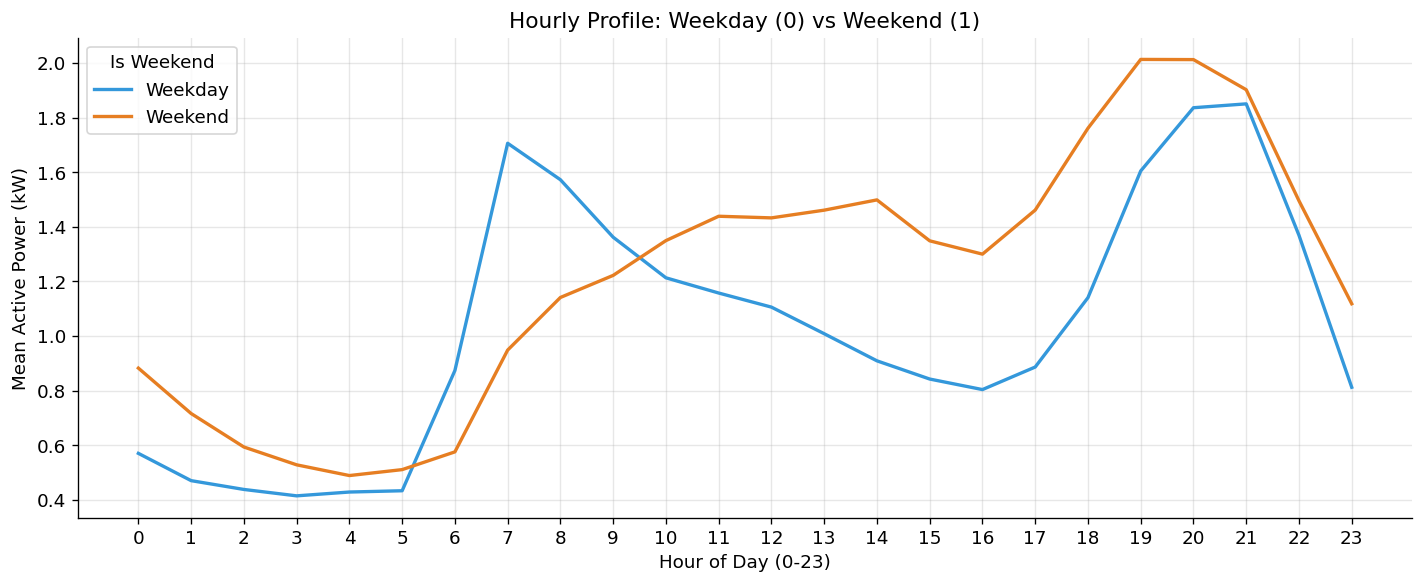

In [8]:
df['DayOfWeek'] = df.index.dayofweek
df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df, x='Hour', y='Global_active_power', hue='Is_Weekend', 
             estimator=np.mean, errorbar=None, palette=['#3498db', '#e67e22'], ax=ax, lw=2)
ax.set_xticks(range(0, 24))
ax.set_title('Hourly Profile: Weekday (0) vs Weekend (1)', fontsize=13)
ax.set_xlabel('Hour of Day (0-23)')
ax.set_ylabel('Mean Active Power (kW)')
ax.legend(title='Is Weekend', labels=['Weekday', 'Weekend'])
plt.tight_layout(); plt.show()

## 8. Sub-metering Composition

How is the total energy divided among the sub-meters (kitchen, laundry, HVAC) and unmetered loads? A stacked area chart visualizes this composition over a typical week.

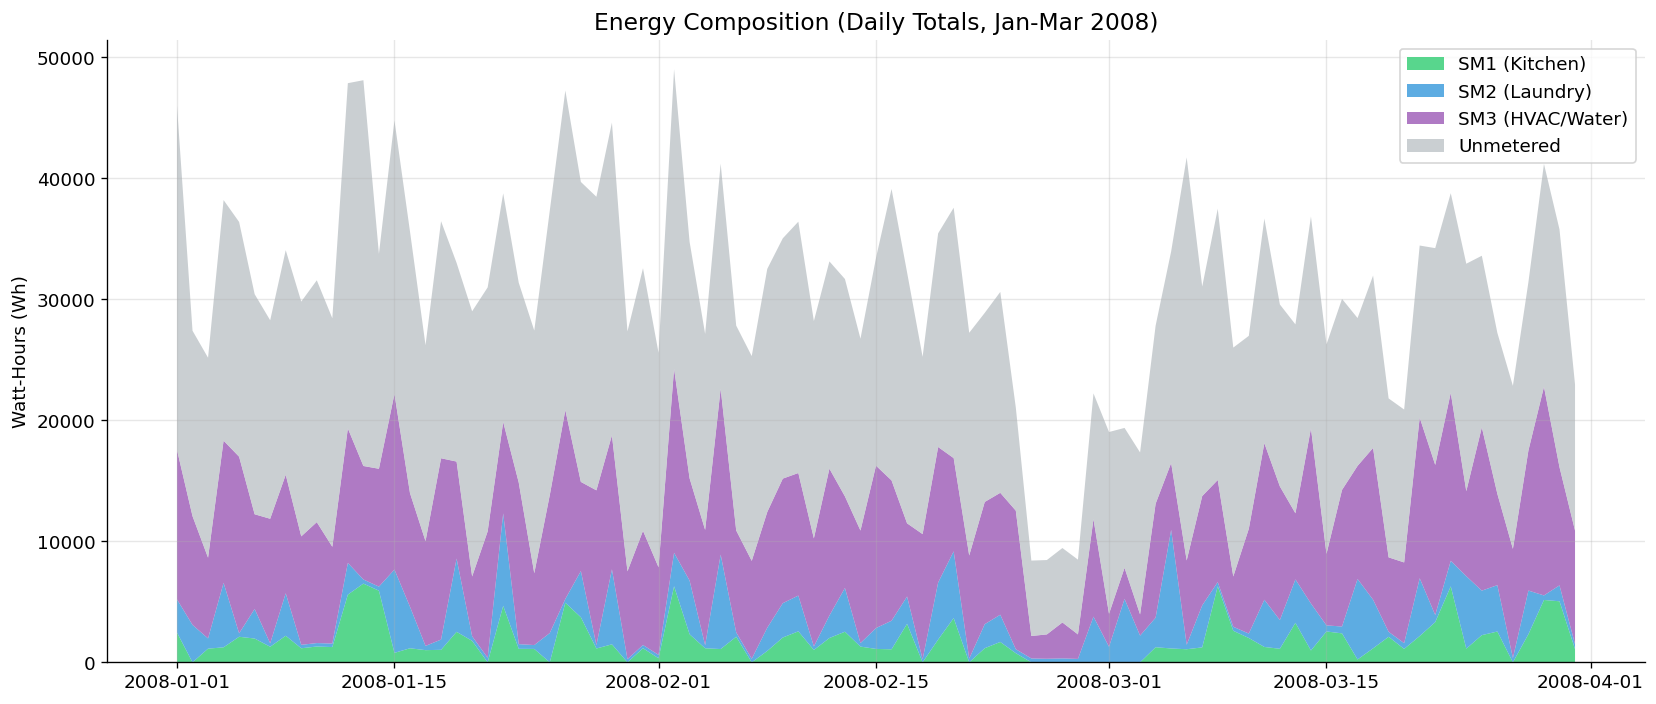

In [9]:
# Resample to daily for smoother visualization of composition
sub_df = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'unmetered_energy']].resample('D').sum()
# Take a slice of 3 months to see variations
sub_slice = sub_df['2008-01-01':'2008-03-31']

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(sub_slice.index, 
             sub_slice['Sub_metering_1'], 
             sub_slice['Sub_metering_2'], 
             sub_slice['Sub_metering_3'], 
             sub_slice['unmetered_energy'],
             labels=['SM1 (Kitchen)', 'SM2 (Laundry)', 'SM3 (HVAC/Water)', 'Unmetered'],
             colors=['#2ecc71', '#3498db', '#9b59b6', '#bdc3c7'], alpha=0.8)

ax.set_title('Energy Composition (Daily Totals, Jan-Mar 2008)', fontsize=14)
ax.set_ylabel('Watt-Hours (Wh)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

## 9. Autocorrelation & Lag Analysis

In time-series forecasting, the past is often the best predictor of the future. Autocorrelation measures how correlated a variable is with delayed (lagged) versions of itself.

We use hourly data to look for 24-hour cycle correlations.

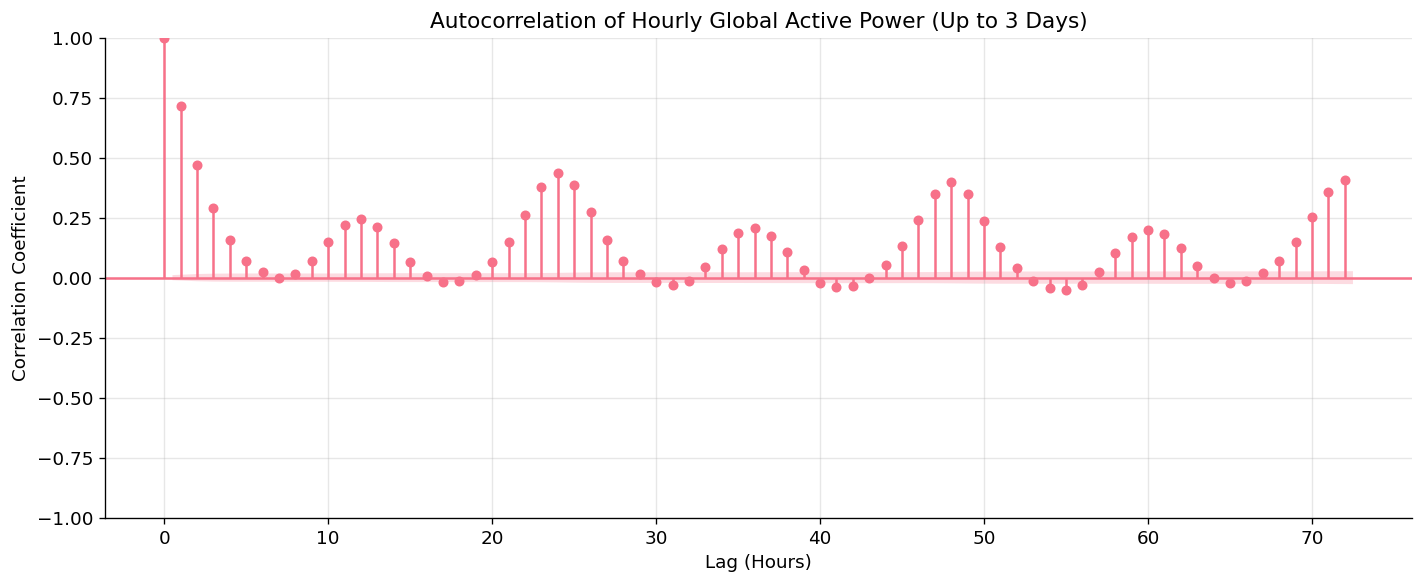

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
# We use statsmodels for a cleaner plot. Lags up to 72 hours (3 days)
sm.graphics.tsa.plot_acf(hourly_df['Global_active_power'].dropna(), lags=72, ax=ax, alpha=0.05)
ax.set_title('Autocorrelation of Hourly Global Active Power (Up to 3 Days)', fontsize=13)
ax.set_xlabel('Lag (Hours)')
ax.set_ylabel('Correlation Coefficient')
plt.tight_layout(); plt.show()

## 10. Rolling Statistics (Volatility & Trend)

Rolling means smooth out short-term fluctuations to highlight longer-term trends. Rolling standard deviations highlight periods of high volatility.

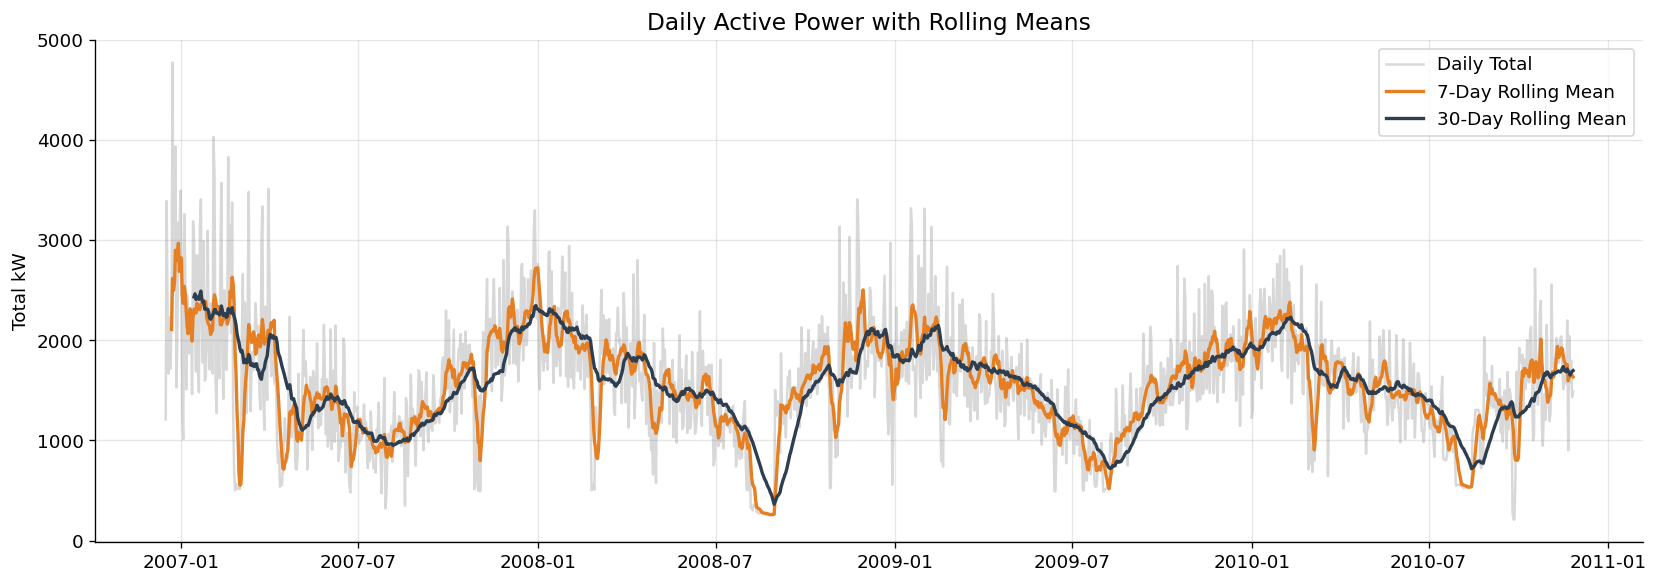

In [11]:
# Calculate 7-day and 30-day rolling averages on daily data
daily_gap = daily_df['Global_active_power']
rolling_7d = daily_gap.rolling(window=7).mean()
rolling_30d = daily_gap.rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_gap.index, daily_gap.values, alpha=0.3, color='gray', label='Daily Total')
ax.plot(rolling_7d.index, rolling_7d.values, color='#e67e22', lw=2, label='7-Day Rolling Mean')
ax.plot(rolling_30d.index, rolling_30d.values, color='#2c3e50', lw=2, label='30-Day Rolling Mean')

ax.set_title('Daily Active Power with Rolling Means', fontsize=14)
ax.set_ylabel('Total kW')
ax.legend()
plt.tight_layout(); plt.show()

## 11. EDA Summary & Feature Engineering Blueprint

### Key Insights Derived:
1. **Strong Multicollinearity:** `Global_active_power` and `Global_intensity` are almost perfectly correlated ($r \approx 0.99$). We should drop one to prevent model instability.
2. **Definitive Seasonality:** Winter months show significantly higher median usage and higher variance compared to summer.
3. **Clear Intraday Cycles:** The "duck curve" is present. Low overnight, morning peak (7-9 AM), and a larger evening peak (7-9 PM).
4. **Weekend Shift:** Weekends lack the sharp morning spike; instead, consumption rises mid-morning and stays elevated throughout the day.
5. **High Autocorrelation at 24h/48h:** Usage at a specific hour today is highly correlated with the same hour yesterday.

### Blueprint for Notebook 03 (Feature Engineering):
- **Time-based Features:** Create cyclic encodings (sine/cosine) for `hour`, `day_of_week`, and `month` to help tree models grasp continuous cycles.
- **Lag Features:** Create $T-1$, $T-24$, and $T-48$ hour lag features.
- **Rolling Features:** Create rolling window statistics (e.g., 6-hour rolling mean).
- **Interaction Terms:** `Is_Weekend` indicator.
- **Drop Redundant Features:** Drop `Global_intensity`.